In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler

from datasets import load_dataset

plt.style.use('ggplot')

import warnings
warnings.filterwarnings(action="ignore")

pd.options.display.float_format = '{:.2f}'.format
plt.rcParams['axes.formatter.useoffset'] = False
import matplotlib.ticker as ticker

import os, pickle

In [4]:
#getting the data
dataset = load_dataset("rahulvyasm/medical_insurance_data")
df = dataset['train'].to_pandas() if 'train' in dataset else dataset.to_pandas()

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


In [11]:
df.region.unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [12]:
df.describe()

,age,bmi,children,charges
count,2772.00,2772.00,2772.00,2772.00
mean,39.11,30.70,1.10,13261.37
std,14.08,6.13,1.21,12151.77
min,18.00,15.96,0.00,1121.87
25%,26.00,26.22,0.00,4687.80
50%,39.00,30.45,1.00,9333.01
75%,51.00,34.77,2.00,16577.78
max,64.00,53.13,5.00,63770.43


In [8]:
def preprocess_df(df):
    """
    Preprocess dataframe:
    - sex: male -> 1, female -> 0
    - smoker: yes -> 1, no -> 0
    - region: one-hot encode and convert to numeric
    """
    df_processed = df.copy()
    
    # Map sex to binary
    df_processed['sex'] = df_processed['sex'].map({'male': 1, 'female': 0})
    
    # Map smoker to binary
    df_processed['smoker'] = df_processed['smoker'].map({'yes': 1, 'no': 0})
    
    # One-hot encode region and convert to numeric
    region_encoded = pd.get_dummies(df_processed['region'], prefix='region', drop_first=False).astype(int)
    df_processed = pd.concat([df_processed, region_encoded], axis=1)
    df_processed = df_processed.drop('region', axis=1)
    
    return df_processed

In [9]:
df_processed = preprocess_df(df)

df_processed.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.92,0,0,0,1
1,18,1,33.77,1,0,1725.55,0,0,1,0
2,28,1,33.00,3,0,4449.46,0,0,1,0
3,33,1,22.70,0,0,21984.47,0,1,0,0
4,32,1,28.88,0,0,3866.86,0,1,0,0


<Axes: >

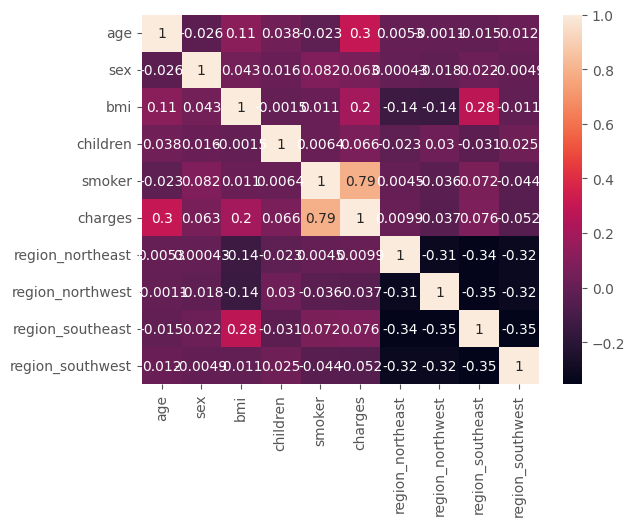

In [15]:
sns.heatmap(df_processed.corr(), annot=True)

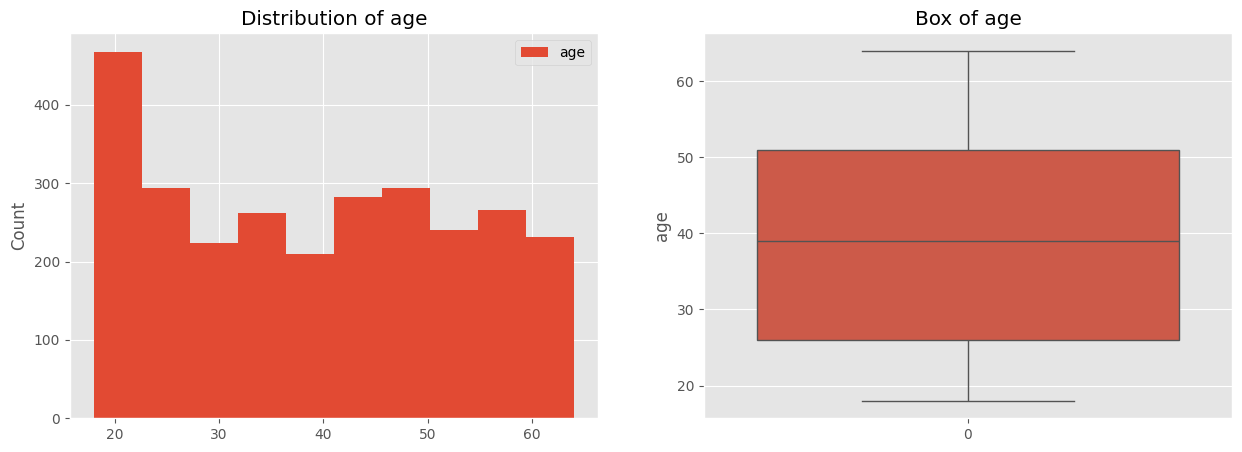

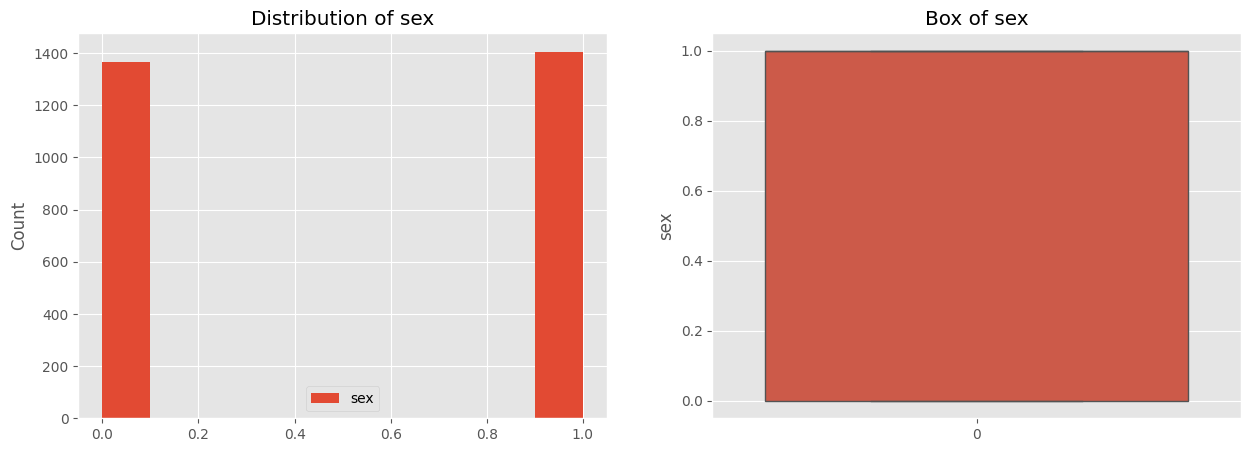

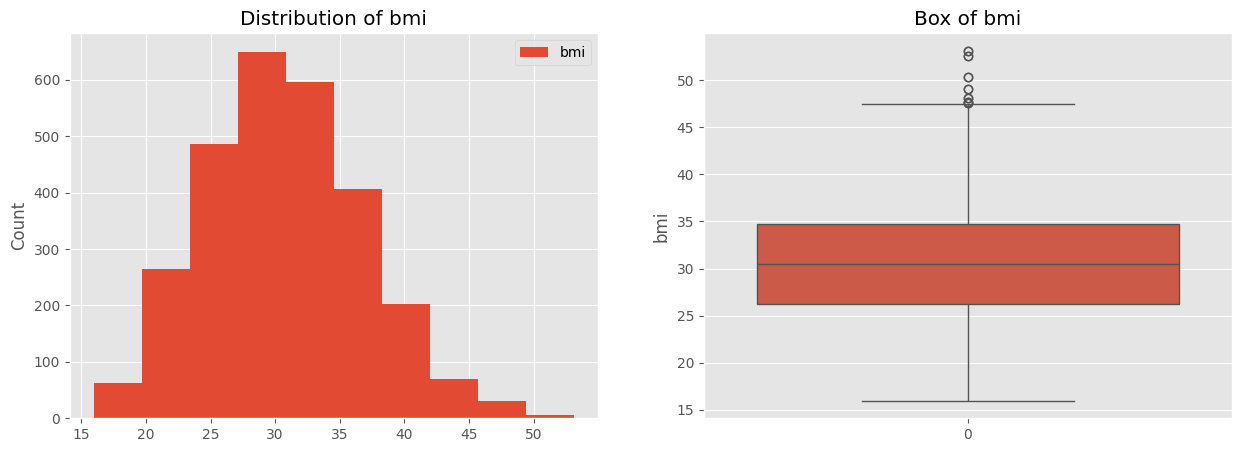

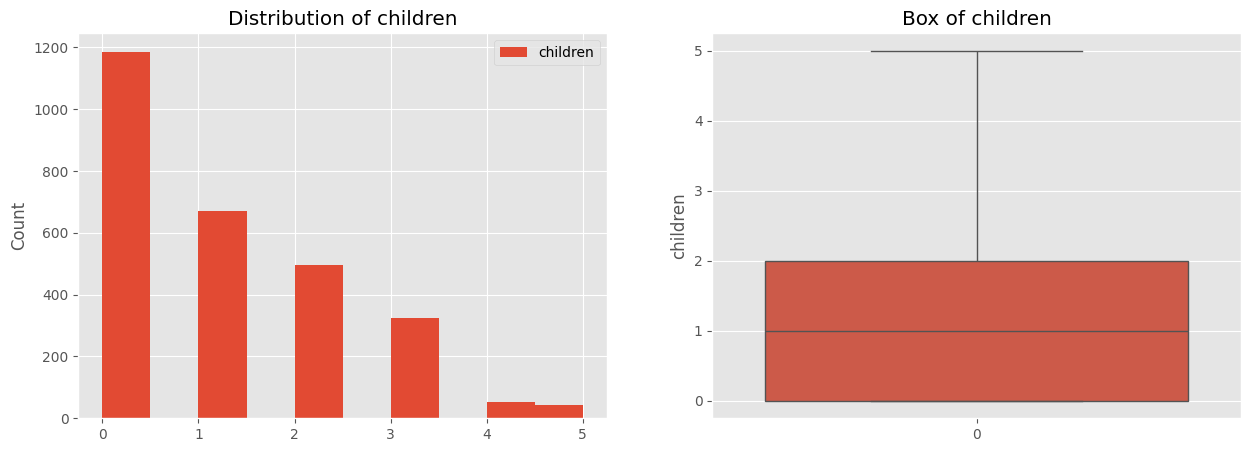

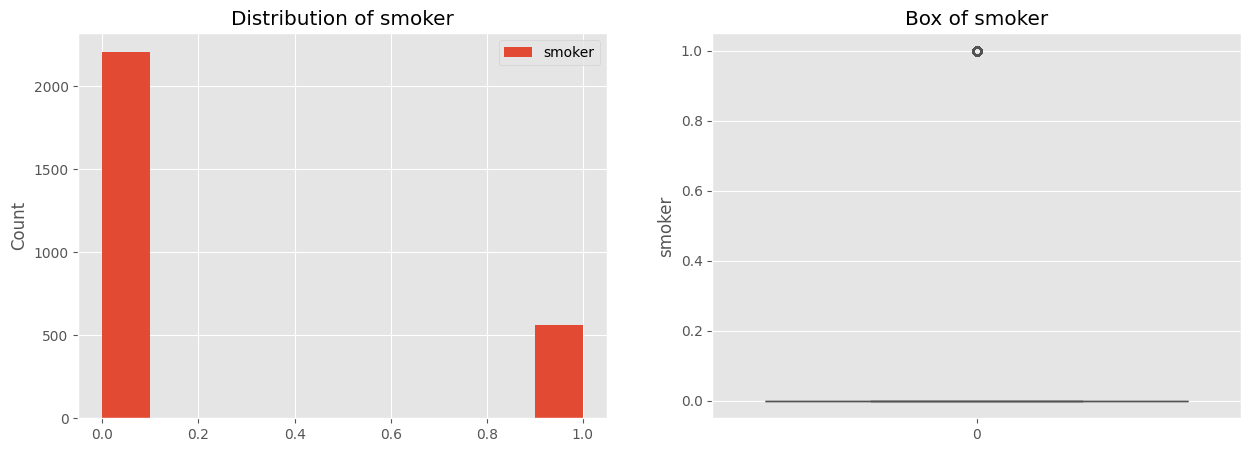

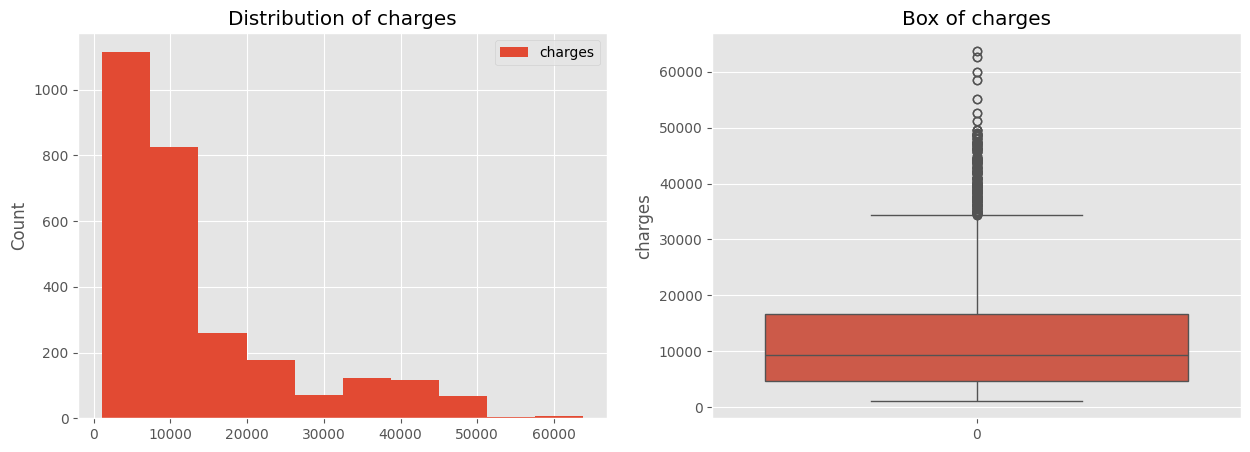

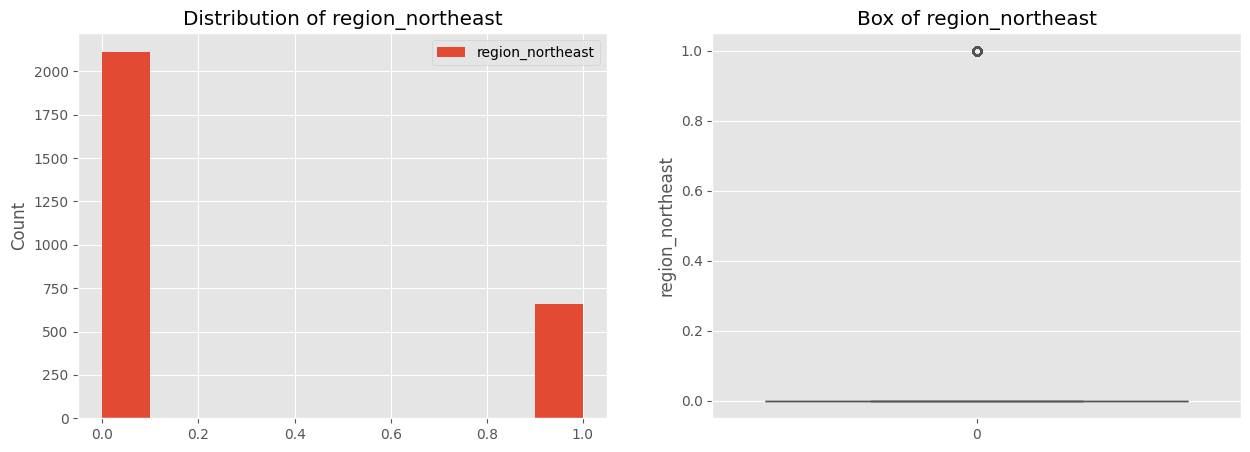

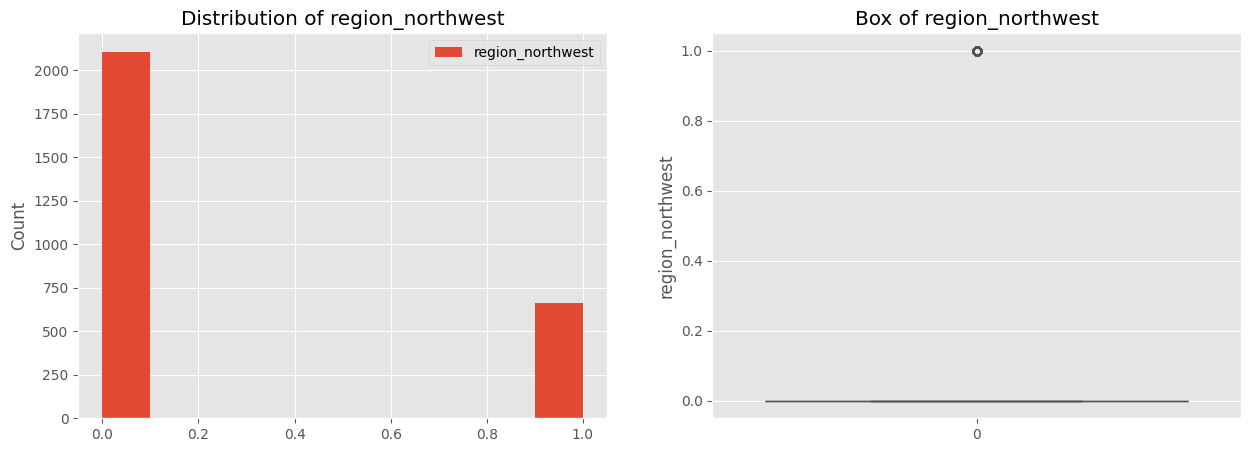

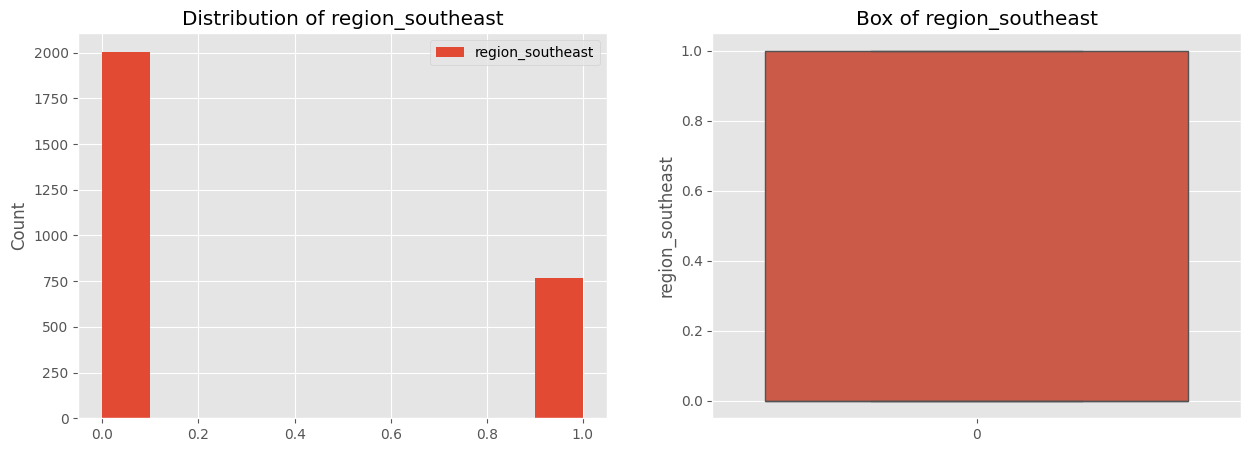

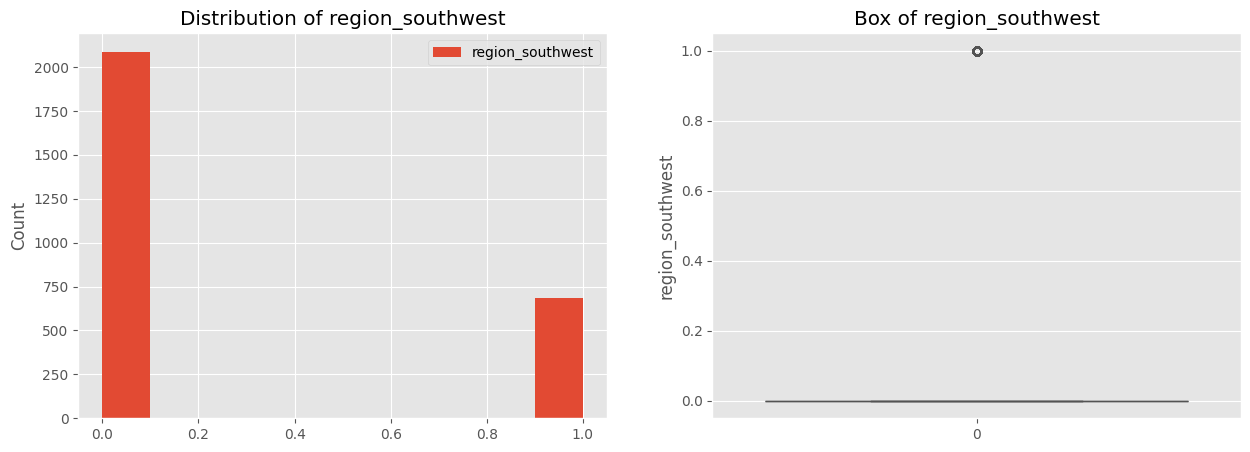

In [17]:
for col in df_processed.columns:
    fig, axes = plt.subplots(1,2, figsize = (15,5))
    df_processed[col].plot(kind='hist', ax=axes[0], legend=True)
    axes[0].set_title('Distribution of {}'.format(col))
    axes[0].set_ylabel('Count')
    sns.boxplot(df_processed[col], ax=axes[1])
    axes[1].set_title('Box of {}'.format(col))

    
    formatter = ticker.ScalarFormatter()
    formatter.set_scientific(False)
    axes[0].xaxis.set_major_formatter(formatter)
    axes[1].xaxis.set_major_formatter(formatter)

    plt.show()

In [20]:
scaler = MinMaxScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(df_processed), columns= df_processed.columns)

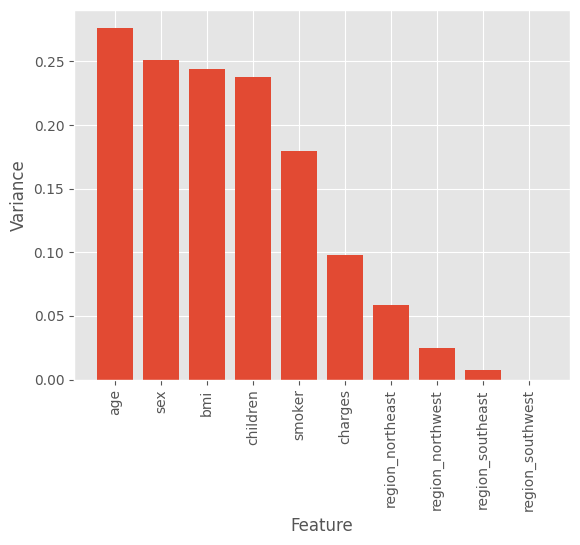

In [24]:
#principal component analysis

pca = PCA()

pca.fit(X_scaled)

plt.bar(X_scaled.columns, pca.explained_variance_)
plt.xticks(X_scaled.columns, rotation=90)
plt.ylabel('Variance')
plt.xlabel('Feature')
plt.show()

2 clusters - 3307.7262169847045 Elbow score.
3 clusters - 2651.7491146573793 Elbow score.
4 clusters - 1733.939842645655 Elbow score.
5 clusters - 1560.3742997088284 Elbow score.
6 clusters - 1416.6340352890252 Elbow score.
7 clusters - 1250.578771941684 Elbow score.


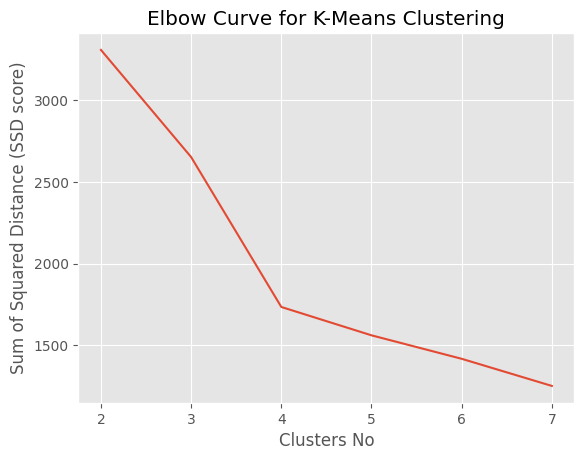

In [25]:
#Tuning a number of clusters with an Elbow method
seed = 42

ssd = []
clusters_list = range(2,8)

for cluster in clusters_list:
    kmeans = KMeans(n_clusters=cluster, max_iter=300, random_state=seed)
    kmeans.fit(X_scaled)
    
    ssd.append(kmeans.inertia_)
    print("{} clusters - {} Elbow score.".format(cluster, kmeans.inertia_))

sns.lineplot(x=clusters_list, y=ssd)
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Clusters No')
plt.ylabel('Sum of Squared Distance (SSD score)')

plt.show()

In [26]:
# recreating a model with the derived parameters

kmeans_model = KMeans(n_clusters=4, max_iter=300, random_state=seed)
kmeans_model.fit(X_scaled)

kmeans_model.labels_

array([1, 3, 3, ..., 2, 2, 1], dtype=int32)

In [27]:
df['cluster'] = kmeans_model.labels_

In [28]:
df.head()

,age,sex,bmi,children,smoker,region,charges,cluster
0,19,female,27.90,0,yes,southwest,16884.92,1
1,18,male,33.77,1,no,southeast,1725.55,3
2,28,male,33.00,3,no,southeast,4449.46,3
3,33,male,22.70,0,no,northwest,21984.47,2
4,32,male,28.88,0,no,northwest,3866.86,2


cluster
3    766
1    684
2    664
0    658
Name: count, dtype: int64

([<matplotlib.axis.XTick at 0x78ab2c209c10>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

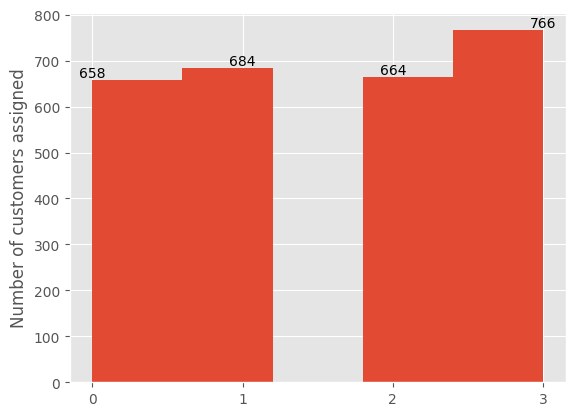

In [29]:
display(df.cluster.value_counts())

df['cluster'].plot(kind='hist', bins=5)
plt.ylabel('Number of customers assigned')

for index, value in enumerate(df.cluster.value_counts().sort_index()):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.xticks(range(len(df['cluster'].unique())))

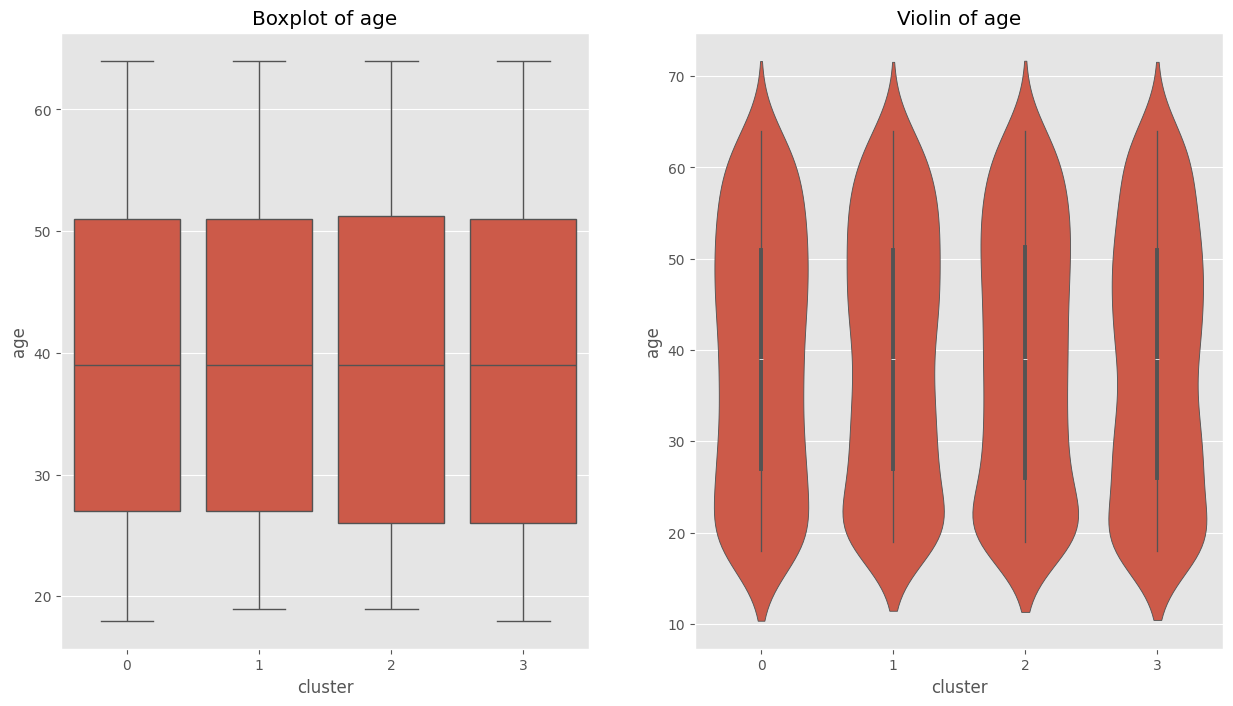

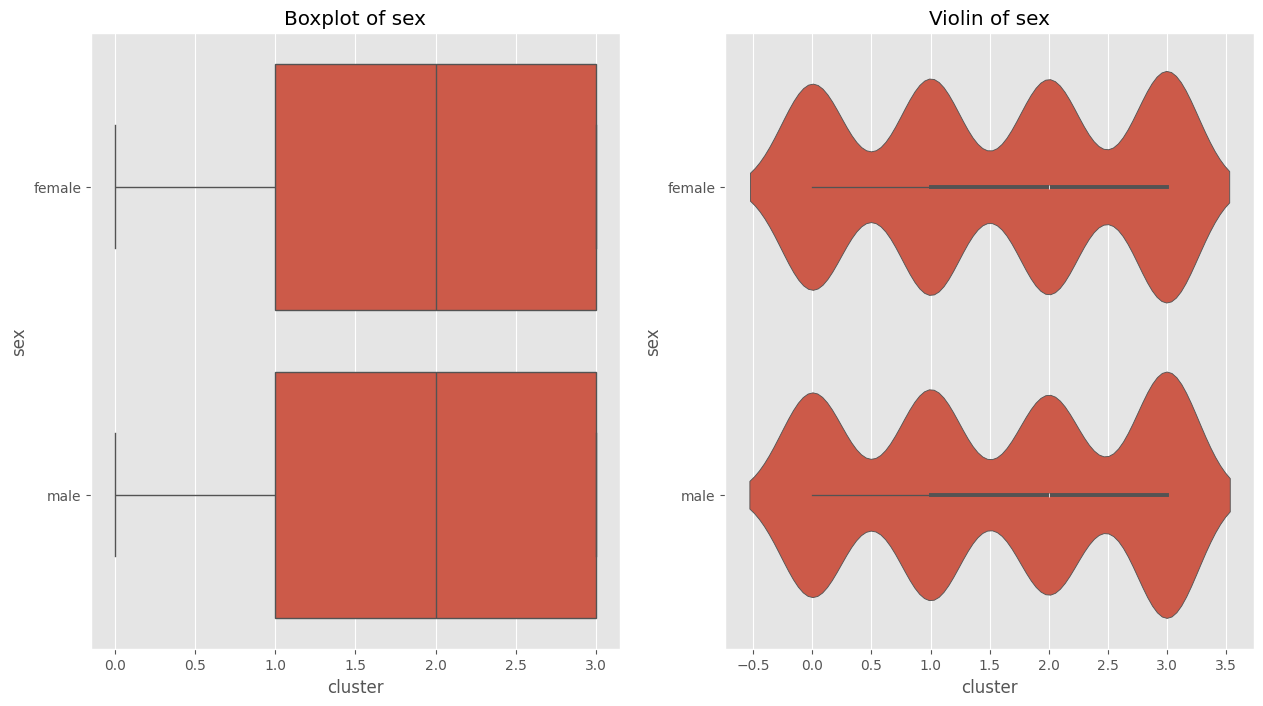

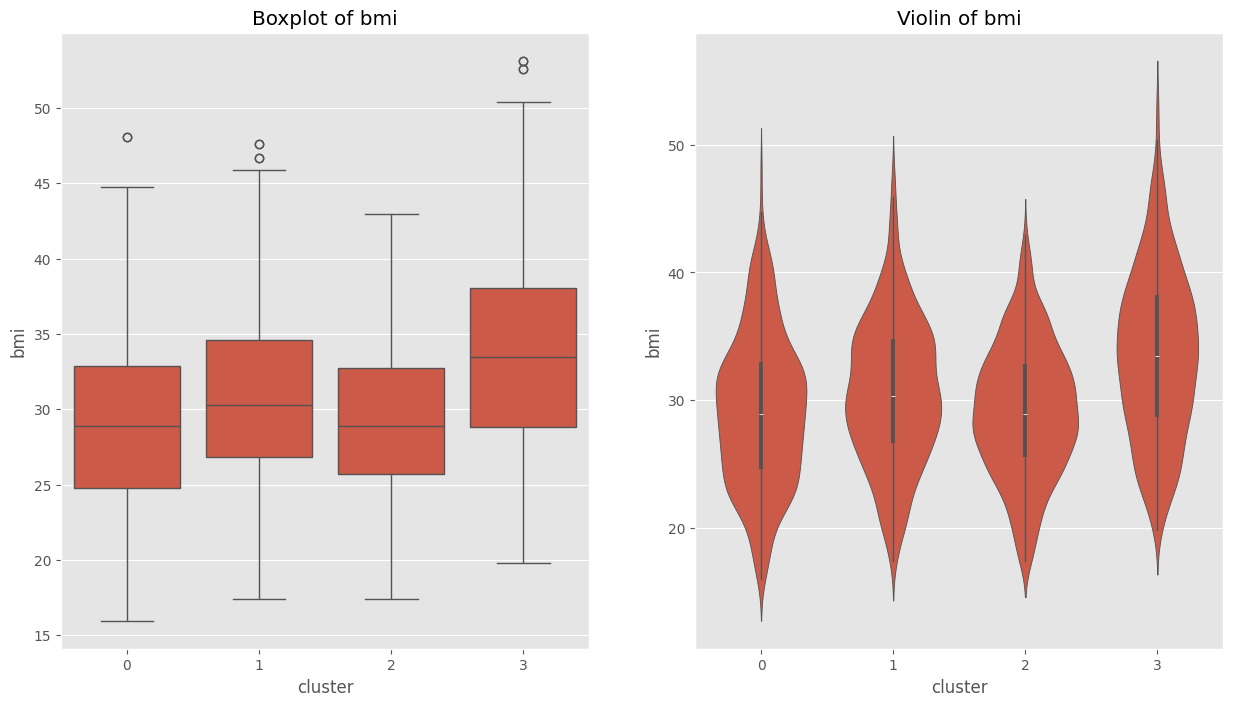

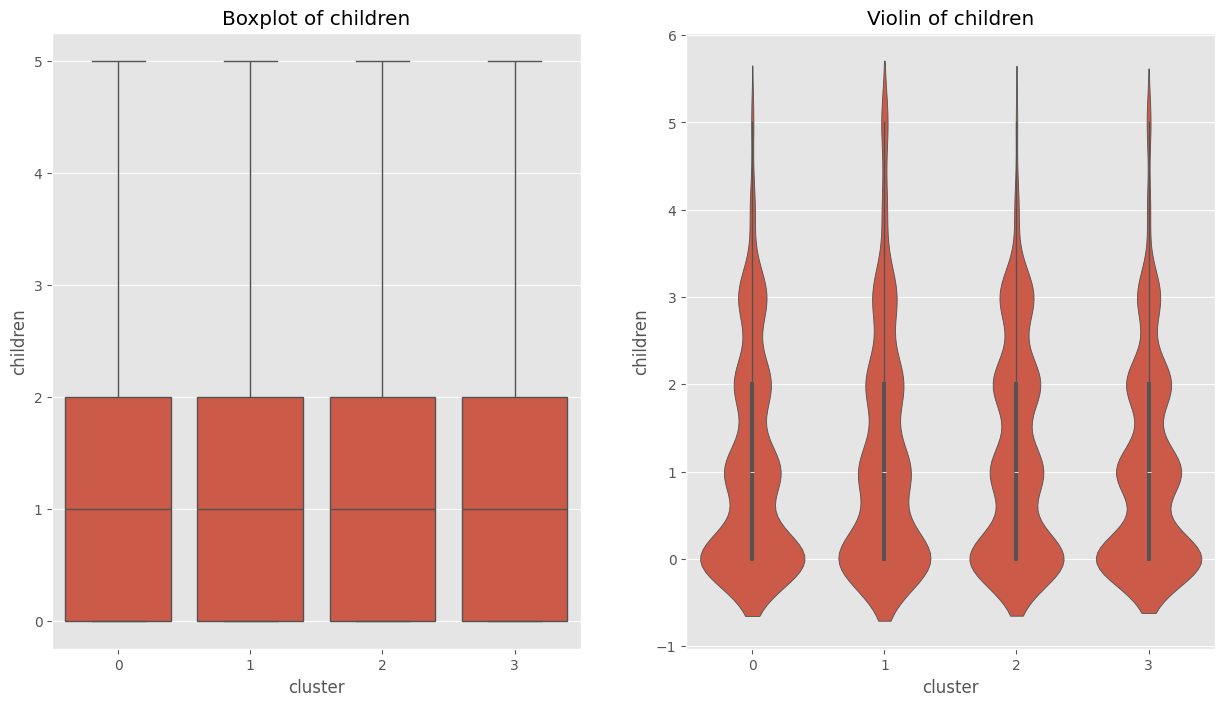

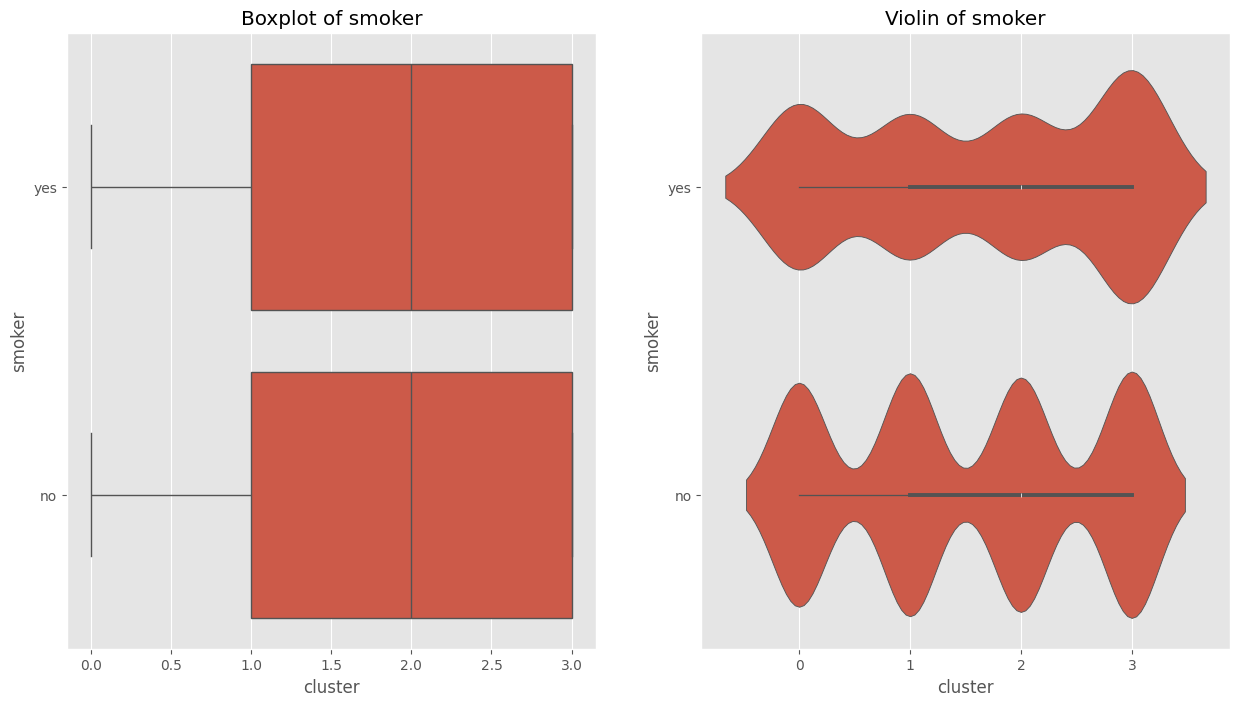

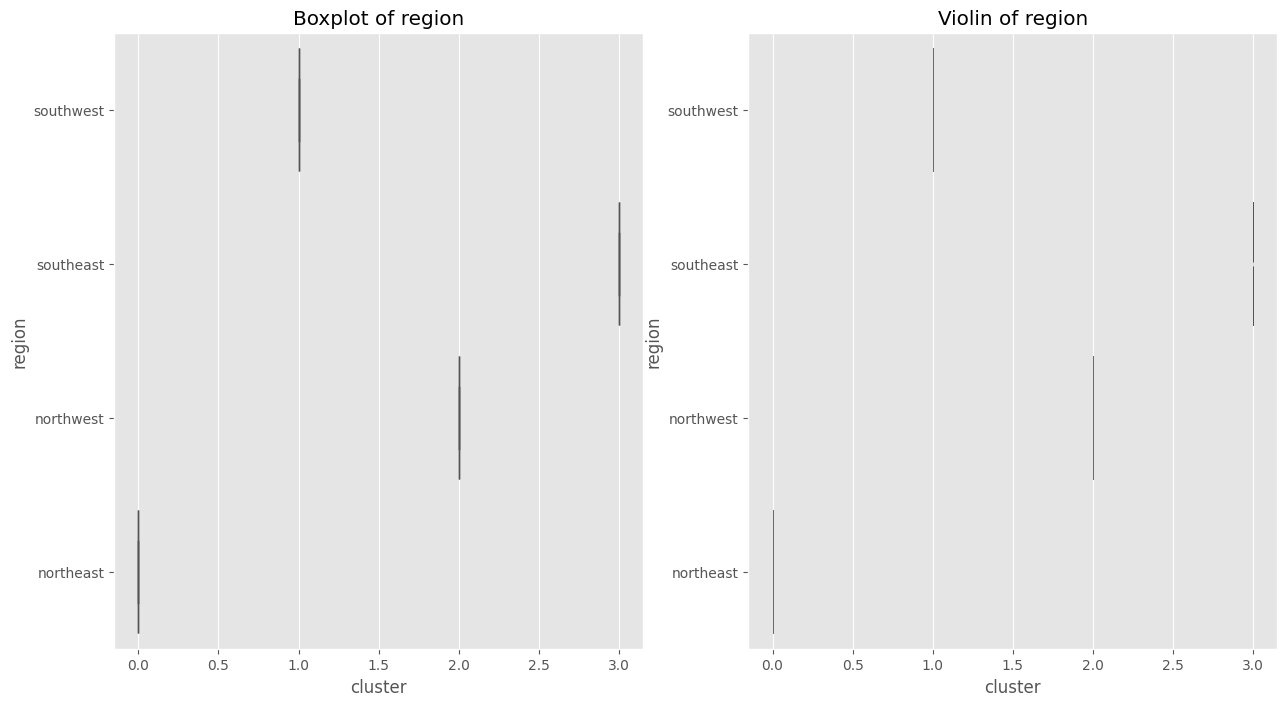

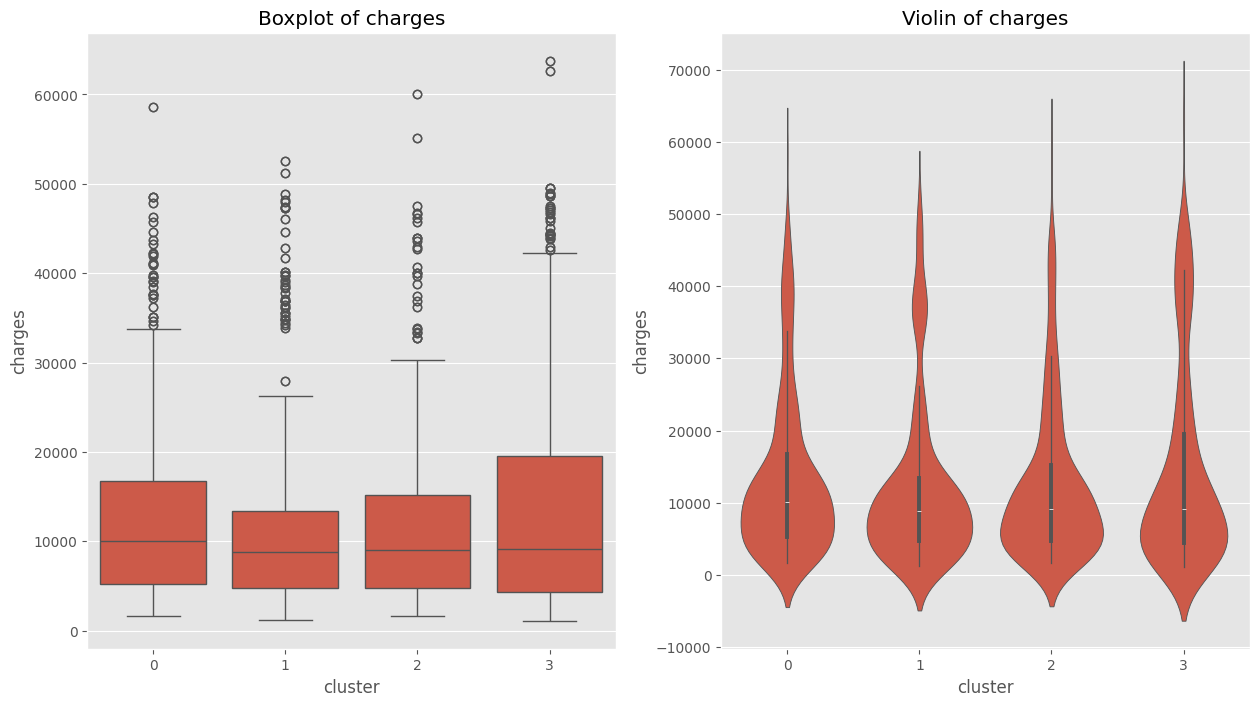

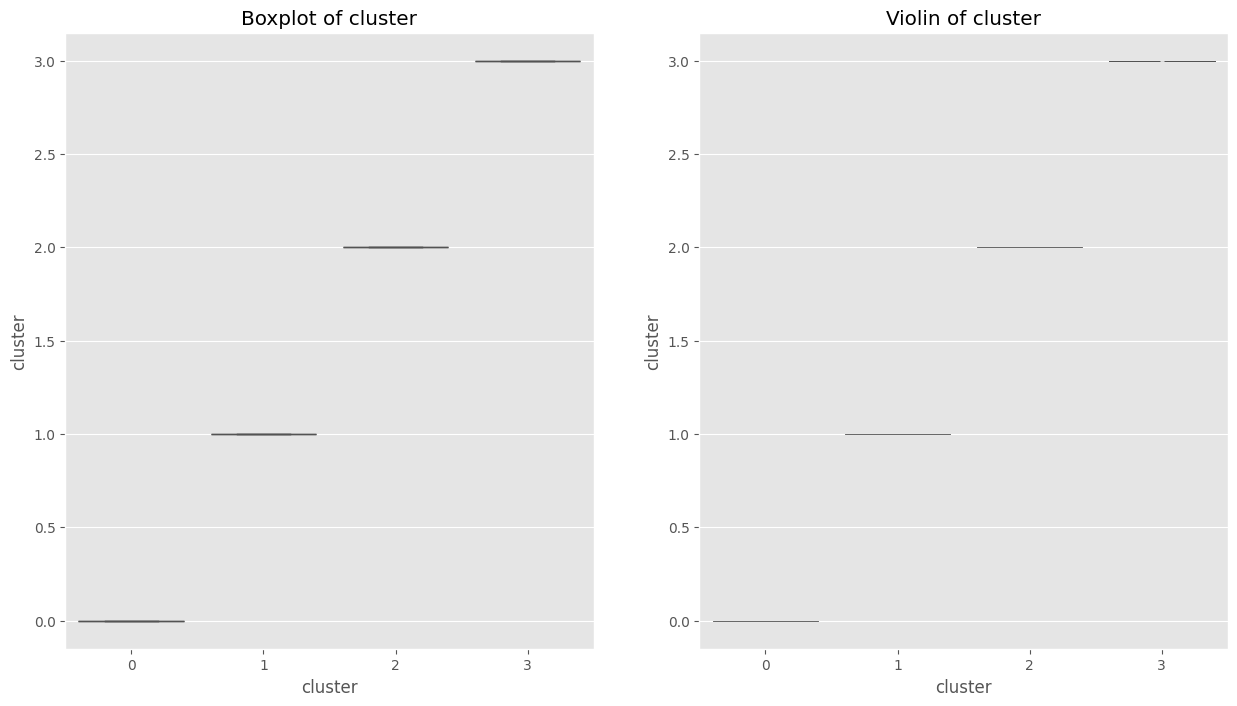

In [30]:
for col in df.columns:
    fig, axes = plt.subplots(1,2, figsize=(15,8))
    sns.boxplot(x='cluster',  y=col, data = df,  ax=axes[0])
    axes[0].set_title('Boxplot of {}'.format(col))
    sns.violinplot(x='cluster',  y=col, data = df,  ax=axes[1])
    axes[1].set_title('Violin of {}'.format(col))
    plt.show()

# out of all observation - higher bmi and lower bmi come with higher charges more ofthen